In [1]:
# Load Model & Data 
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
MODEL_PATH  = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\models"
RESULT_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results"

# Load model and data
print("Loading model and data...")
rf          = joblib.load(f"{MODEL_PATH}\\random_forest.pkl")
le          = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")
feature_names = joblib.load(f"{DATA_PATH}\\feature_names.pkl")
X_test      = joblib.load(f"{DATA_PATH}\\X_test.pkl")
y_test      = joblib.load(f"{DATA_PATH}\\y_test.pkl")

print(f"Model loaded: Random Forest")
print(f"Test set    : {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"Classes     : {list(le.classes_)}")

# Use a stratified sample for SHAP — full test set is too large
# Sample 500 instances stratified across classes
np.random.seed(42)
sample_idx = []
unique_classes = np.unique(y_test)
for cls in unique_classes:
    cls_idx = np.where(y_test == cls)[0]
    n = min(50, len(cls_idx))  # up to 50 per class
    sample_idx.extend(np.random.choice(cls_idx, n, replace=False))

X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

print(f"\nSHAP sample: {len(X_sample)} instances")
print(f"Class distribution in sample:")
unique, counts = np.unique(y_sample, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:<40} {c}")

Loading model and data...
Model loaded: Random Forest
Test set    : 504,160 samples x 47 features
Classes     : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

SHAP sample: 613 instances
Class distribution in sample:
  BENIGN                                   50
  Bot                                      50
  DDoS                                     50
  DoS GoldenEye                            50
  DoS Hulk                                 50
  DoS Slowhttptest                         50
  DoS slowloris                            50
  FTP-Patator                              50
  Heartbleed                               2
  Infiltration                             7
  PortScan                                 50
  SSH-Patator                              50
  Web Attack � Brute Force            

In [2]:
# Compute SHAP Values
import time

print("Computing SHAP values using TreeExplainer...")

start = time.time()

# TreeExplainer is optimised for Random Forest and XGBoost
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

elapsed = time.time() - start
print(f"SHAP values computed in {elapsed/60:.1f} minutes")
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"  Dimensions: [classes x samples x features]")
print(f"  Samples    : {len(shap_values)}")
print(f"  Features    : {shap_values[0].shape[0]}")
print(f"  Classes   : {shap_values[0].shape[1]}")

# Save SHAP values for later use
joblib.dump(shap_values, f"{DATA_PATH}\\shap_values.pkl")
joblib.dump(X_sample,    f"{DATA_PATH}\\X_sample.pkl")
joblib.dump(y_sample,    f"{DATA_PATH}\\y_sample.pkl")
print("\nSHAP values saved to disk")

Computing SHAP values using TreeExplainer...
SHAP values computed in 4.5 minutes
SHAP values shape: (613, 47, 15)
  Dimensions: [classes x samples x features]
  Samples    : 613
  Features    : 47
  Classes   : 15

SHAP values saved to disk


Generating global SHAP summary plot...
mean_abs_shap shape: (47,)
feature_names count: 47


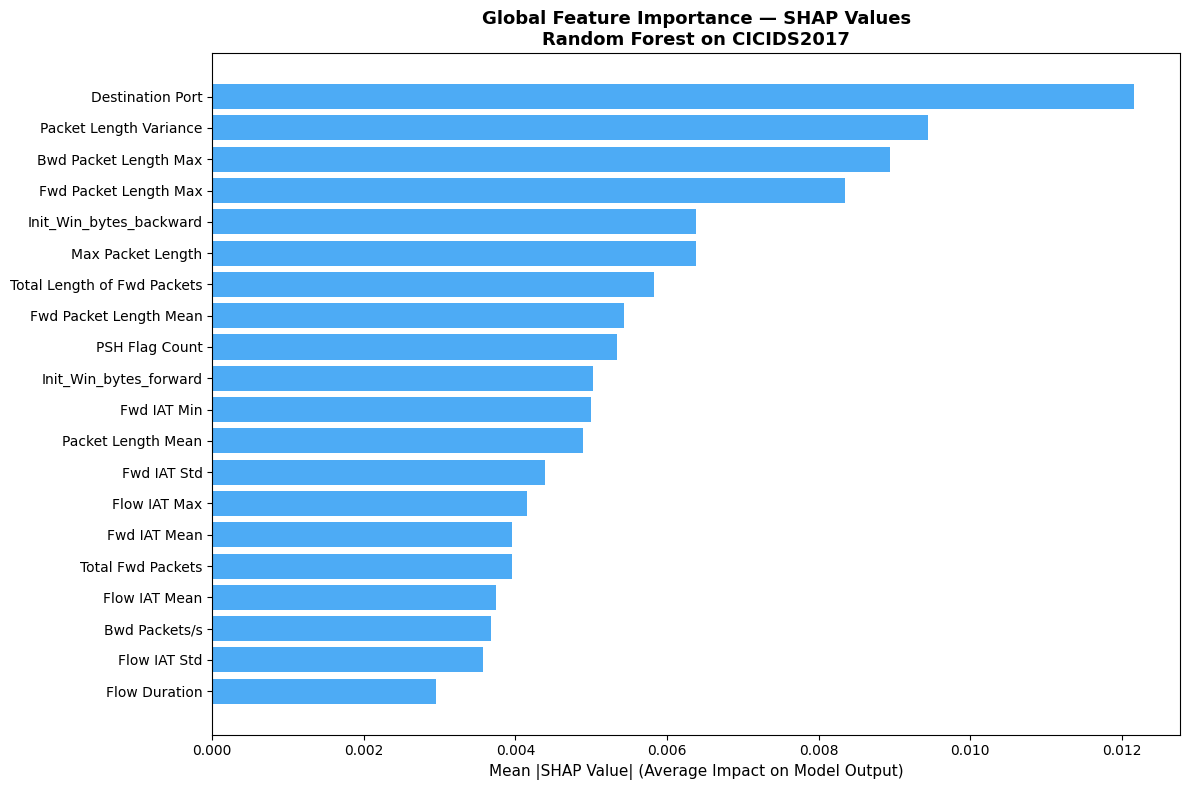


Top 20 most important features globally:
Rank  Feature                             Mean |SHAP|
-------------------------------------------------------
1     Destination Port                    0.012161
2     Packet Length Variance              0.009450
3     Bwd Packet Length Max               0.008949
4     Fwd Packet Length Max               0.008351
5     Init_Win_bytes_backward             0.006384
6     Max Packet Length                   0.006383
7     Total Length of Fwd Packets         0.005823
8     Fwd Packet Length Mean              0.005429
9     PSH Flag Count                      0.005343
10    Init_Win_bytes_forward              0.005021
11    Fwd IAT Min                         0.004993
12    Packet Length Mean                  0.004896
13    Fwd IAT Std                         0.004394
14    Flow IAT Max                        0.004148
15    Fwd IAT Mean                        0.003961
16    Total Fwd Packets                   0.003953
17    Flow IAT Mean             

In [3]:
# Global SHAP Summary Plot 
print("Generating global SHAP summary plot...")

# SHAP values shape is (613, 47, 15) — samples x features x classes
# Reorder to (15, 613, 47) — classes x samples x features
shap_values_array = np.array(shap_values)  # shape: (613, 47, 15)
shap_reordered = np.transpose(shap_values_array, (2, 0, 1))  # shape: (15, 613, 47)

# Mean absolute SHAP value per feature across all classes and samples
mean_abs_shap = np.mean(np.abs(shap_reordered), axis=(0, 1))  # shape: (47,)

print(f"mean_abs_shap shape: {mean_abs_shap.shape}")
print(f"feature_names count: {len(feature_names)}")

# Sort features by importance
sorted_idx = np.argsort(mean_abs_shap)[::-1]
top_n = min(20, len(feature_names))

plt.figure(figsize=(12, 8))
plt.barh(
    range(top_n),
    mean_abs_shap[sorted_idx[:top_n]][::-1],
    color='#2196F3', alpha=0.8
)
plt.yticks(
    range(top_n),
    [feature_names[i] for i in sorted_idx[:top_n]][::-1],
    fontsize=10
)
plt.xlabel('Mean |SHAP Value| (Average Impact on Model Output)', fontsize=11)
plt.title('Global Feature Importance — SHAP Values\nRandom Forest on CICIDS2017',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}\\shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 20 most important features globally:")
print(f"{'Rank':<5} {'Feature':<35} {'Mean |SHAP|'}")
print("-" * 55)
for rank, idx in enumerate(sorted_idx[:20]):
    print(f"{rank+1:<5} {feature_names[idx]:<35} {mean_abs_shap[idx]:.6f}")

Generating SHAP beeswarm plots per attack class...


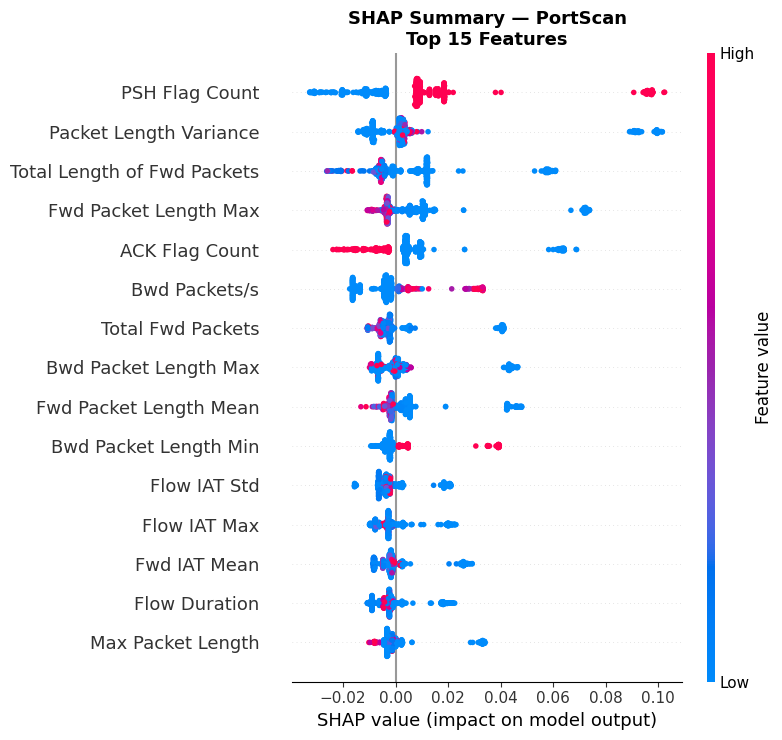

  Saved: shap_summary_PortScan.png


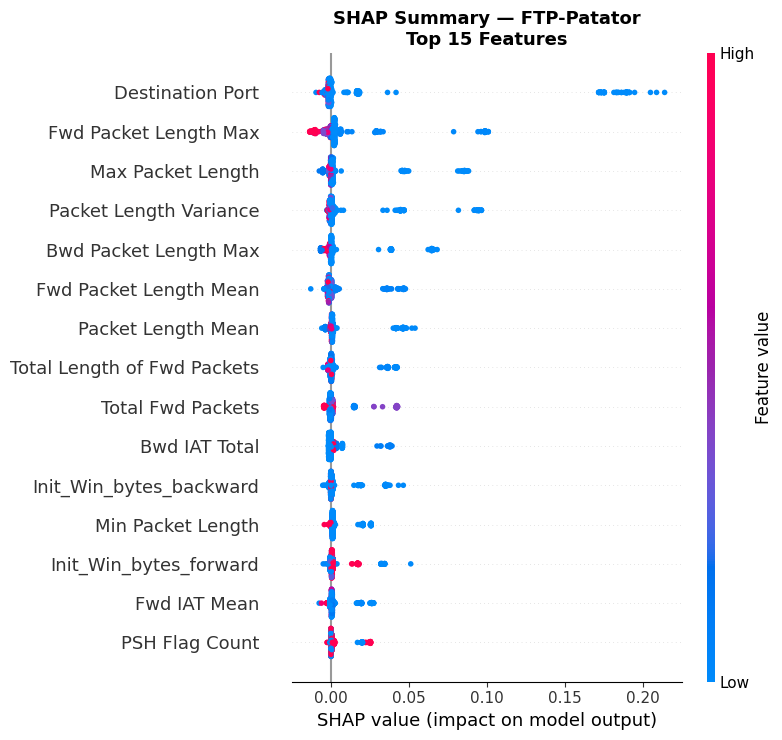

  Saved: shap_summary_FTP_Patator.png


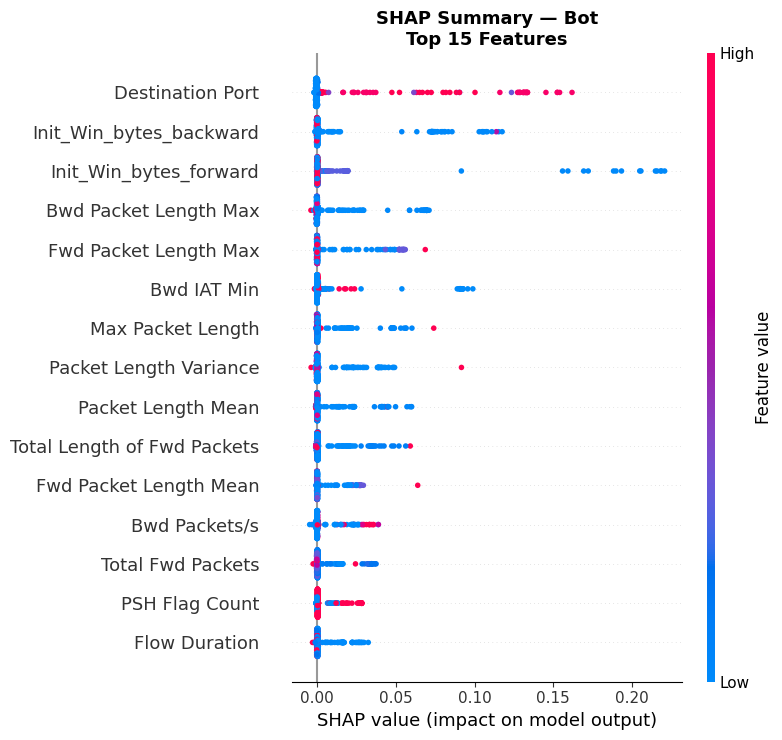

  Saved: shap_summary_Bot.png

All beeswarm plots saved to results folder


In [4]:
# SHAP Beeswarm Plots 
print("Generating SHAP beeswarm plots per attack class...")

# Class indices in le.classes_:
# 0=BENIGN, 1=Bot, 2=DDoS, 3=DoS GoldenEye, 4=DoS Hulk
# 5=DoS Slowhttptest, 6=DoS slowloris, 7=FTP-Patator
# 8=Heartbleed, 9=Infiltration, 10=PortScan
# 11=SSH-Patator, 12=Web Attack Brute Force
# 13=Web Attack Sql Injection, 14=Web Attack XSS

attack_classes = {
    10: 'PortScan',
    7 : 'FTP-Patator',
    1 : 'Bot'
}

for class_idx, class_name in attack_classes.items():
    # shap_reordered shape: (15, 613, 47) — index by class first
    shap_for_class = shap_reordered[class_idx]  # shape: (613, 47)

    plt.figure(figsize=(12, 7))
    shap.summary_plot(
        shap_for_class,
        X_sample,
        feature_names=feature_names,
        max_display=15,
        show=False,
        plot_type='dot'
    )
    plt.title(f'SHAP Summary — {class_name}\nTop 15 Features',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_name = class_name.replace(' ', '_').replace('-', '_')
    plt.savefig(
        f"{RESULT_PATH}\\shap_summary_{save_name}.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"  Saved: shap_summary_{save_name}.png")

print("\nAll beeswarm plots saved to results folder")

In [5]:
# Get FTP-Patator SHAP values 
import numpy as np
import joblib

DATA_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
RESULT_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results"

# Load saved SHAP values
shap_values = joblib.load(f"{DATA_PATH}\\shap_values.pkl")
feature_names = joblib.load(f"{DATA_PATH}\\feature_names.pkl")
y_sample = joblib.load(f"{DATA_PATH}\\y_sample.pkl")
le = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")

# Reorder SHAP array: (613, 47, 15) -> (15, 613, 47)
shap_array = np.array(shap_values)
shap_reordered = np.transpose(shap_array, (2, 0, 1))

# FTP-Patator is class index 7
ftp_class_idx = 7

# Get indices of FTP-Patator instances in the sample
ftp_instance_idx = np.where(y_sample == ftp_class_idx)[0]
print(f"FTP-Patator instances in sample: {len(ftp_instance_idx)}")

# Get SHAP values for FTP-Patator instances, for FTP-Patator class
ftp_shap = shap_reordered[ftp_class_idx, ftp_instance_idx, :]

# Calculate mean absolute SHAP per feature
mean_abs_ftp = np.mean(np.abs(ftp_shap), axis=0)

# Sort by importance
sorted_idx = np.argsort(mean_abs_ftp)[::-1]

print(f"\nFTP-Patator — Top 15 SHAP Feature Values:")
print(f"{'Rank':<5} {'Feature':<35} {'Mean |SHAP|':>12}")
print("-" * 55)
for rank, idx in enumerate(sorted_idx[:15]):
    print(f"{rank+1:<5} {feature_names[idx]:<35} {mean_abs_ftp[idx]:>12.6f}")

FTP-Patator instances in sample: 50

FTP-Patator — Top 15 SHAP Feature Values:
Rank  Feature                              Mean |SHAP|
-------------------------------------------------------
1     Destination Port                        0.183029
2     Packet Length Variance                  0.066903
3     Max Packet Length                       0.064347
4     Fwd Packet Length Max                   0.060288
5     Bwd Packet Length Max                   0.052521
6     Packet Length Mean                      0.044514
7     Fwd Packet Length Mean                  0.040012
8     Total Length of Fwd Packets             0.038356
9     Total Fwd Packets                       0.028731
10    Init_Win_bytes_backward                 0.027854
11    Init_Win_bytes_forward                  0.024632
12    Bwd IAT Total                           0.023089
13    Min Packet Length                       0.022579
14    PSH Flag Count                          0.022455
15    Fwd IAT Mean                      